<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>


# PrimateFace Tutorial: Automated Face Recognition Pipeline

| GitHub | Paper | Website |
|---|---|---|
| [Code](https://github.com/KordingLab/PrimateFace) | [Preprint](https://www.biorxiv.org/content/10.1101/2025.08.12.669927) | [Project](https://primateface.studio/) |

Welcome! This tutorial notebook demonstrates a complete, closed-set face recognition pipeline. That is, given a set of images with corresponding primate IDs, we will chain together PrimateFace models with off-the-shelf face recognition models to achieve rapid identity recognition.

In this notebook, we use the ['Macaque Faces' dataset published by Witham & Bethell (2019)](https://figshare.com/articles/dataset/Macaque_Faces/9862586).

### This notebook will:

1.  **Set up the environment** with all necessary deep learning libraries (MMDetection, MMPose, InsightFace, Scikit-learn).
2.  **Download pre-trained models** for face detection and facial landmark estimation.
3.  **Load your dataset**, either by creating a mock dataset or by connecting to your own image folder in Google Drive.
4.  **Run the full pipeline:**
    *   **Detect** faces in each image using an MMDetection model.
    *   **Estimate Pose** by finding 68 facial landmarks using an MMPose model.
    *   **Align** and crop each face to a standardized 112x112 size.
    *   **Extract Embeddings** by converting each aligned face into a unique feature vector using an InsightFace (ArcFace) model.
    *   **Train a Classifier** to recognize individuals based on their face embeddings.
5.  **Evaluate Performance** by generating a t-SNE plot, a confusion matrix, and ROC curves.
6.  **Run a Shuffle Control** experiment to validate that the classifier is learning meaningful features.

---
### **Quick Start Instructions**

*   **Set Your Runtime to GPU**: Go to **Runtime > Change runtime type > T4 GPU**. This is essential for performance.
*   **Run Cells Sequentially**: Click the "Play" button on each cell to run it. The initial setup cells can take several minutes.
*   **Restarting**: Installing the dependencies requires restarting the Runtime. You can do this by clicking the "Runtime" menu and selecting "Restart session". After restarting, you must **rerun the setup cells** before continuing.

Let's begin!

## 1. Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from notebook_utils import (
    check_environment, get_device, download_models_hf,
    init_models, setup_publication_style, save_fig,
)

env_info = check_environment(require_packages=["mmdet", "mmpose", "insightface", "onnxruntime"])
DEVICE = get_device()
print()
print(f"Using device: {DEVICE}")

setup_publication_style()

PrimateFace Environment
  Python:   3.10.18
  PyTorch:  2.1.0+cu118
  CUDA:     True
  Device:   cuda:0
  GPU:      NVIDIA GeForce RTX 4090 (25.8 GB)
  mmdet: 3.2.0 [OK]
  mmpose: 1.3.2 [OK]
  insightface: 0.7.3 [OK]
  onnxruntime: 1.23.2 [OK]

Using device: cuda:0
Publication plot style configured (Nature-style).


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pathlib import Path
from PIL import Image
import requests
import io
import itertools
from tqdm.notebook import tqdm
import os
import shutil
import glob
from typing import List, Tuple, Dict, Any
import cv2
import argparse

from mmdet.apis import init_detector, inference_detector
from mmengine.utils import check_file_exist
from mmengine.config import Config

from mmpose.apis import init_model as init_mmpose_model, inference_topdown
from mmpose.structures import merge_data_samples as merge_mmpose_data_samples
from mmpose.utils import adapt_mmdet_pipeline
from insightface.model_zoo import get_model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_curve, precision_recall_curve, auc, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import shuffle as sk_shuffle

# For displaying results
from IPython.display import display, Image as IPImage

## 2. Download Models & Set Up Functions

Here, we'll download the pre-trained models needed for our pipeline:
1.  **Face Detector**: An MMDetection model to find faces in images.
2.  **Pose Estimator**: An MMPose model to find 68 key facial landmarks.

The **Face Recognizer** (InsightFace) will be downloaded automatically by its library in the next step.


In [3]:
# Model paths
NOTEBOOK_DIR = Path.cwd()
DEMOS_DIR = NOTEBOOK_DIR.parent

# Download models from HuggingFace (skips if already present)
model_paths = download_models_hf(DEMOS_DIR)

MMDET_CONFIG_PATH = str(model_paths["mmdet_config.py"])
MMDET_CHECKPOINT_PATH = str(model_paths["mmdet_checkpoint.pth"])
MMPOSE_CONFIG_PATH = str(model_paths["mmpose_config.py"])
MMPOSE_CHECKPOINT_PATH = str(model_paths["mmpose_checkpoint.pth"])

print()
print(f"Device: {DEVICE}")

  Downloading: mmdet_config.py ...


cascade_rcnn_r101_fpn_config.py: 0.00B [00:00, ?B/s]

C:\ProgramData\miniconda3\envs\primateface\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Felipe Parodi\.cache\huggingface\hub\models--fparodi--primateface-models. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling ba

    Saved: mmdet_config.py (0.0 MB)
  Downloading: mmdet_checkpoint.pth ...


cascade_rcnn_r101_fpn.pth:   0%|          | 0.00/356M [00:00<?, ?B/s]

...

vitpose_base_68kpt_config.py: 0.00B [00:00, ?B/s]

    Saved: vitpose_config.py (0.0 MB)
  Downloading: vitpose_checkpoint.pth ...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


vitpose_base_68kpt.pth:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

    Saved: vitpose_checkpoint.pth (1192.4 MB)

Device: cuda:0


In [4]:
# Load InsightFace ArcFace model
from insightface.app import FaceAnalysis

# InsightFace downloads its own models automatically on first use
INSIGHTFACE_MODEL_NAME = "buffalo_l"
print(f"InsightFace model: {INSIGHTFACE_MODEL_NAME}")
print("Note: InsightFace will download model weights automatically on first use.")

# Initialize InsightFace recognition model
app = None
rec_model = None

try:
    app = FaceAnalysis(
        name=INSIGHTFACE_MODEL_NAME,
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    app.prepare(ctx_id=0, det_size=(640, 640))

    if hasattr(app, 'models') and 'recognition' in app.models:
        rec_model = app.models['recognition']
        print("InsightFace app and recognition model loaded successfully.")
        if hasattr(rec_model, 'session') and hasattr(rec_model.session, 'get_providers'):
            print(f"ONNX session active providers: {rec_model.session.get_providers()}")
    else:
        print("ERROR: Recognition model not found in FaceAnalysis app.models")

except Exception as e:
    print(f"CRITICAL ERROR: Could not load InsightFace model via FaceAnalysis: {e}")
    print("The rest of the pipeline will likely fail.")

InsightFace model: buffalo_l
Note: InsightFace will download model weights automatically on first use.
download_path: C:\Users\Felipe Parodi/.insightface\models\buffalo_l


  0%|          | 0/281857 [00:00<?, ?KB/s]

  4%|▍         | 10620/281857 [00:00<00:02, 96373.43KB/s]

  8%|▊         | 23249/281857 [00:00<00:02, 106860.01KB/s]

 13%|█▎        | 36140/281857 [00:00<00:02, 111495.97KB/s]

...

100%|██████████| 281857/281857 [00:02<00:00, 110479.23KB/s]

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Felipe Parodi/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\Felipe Parodi/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Felipe Parodi/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Felipe Parodi/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Felipe Parodi/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
InsightFace app and recognition model loaded successfully.
ONNX session active providers: ['CPUExecutionProvider']


In [5]:

# --- Facial Landmark Constants for Alignment ---
# Face alignment constants imported from PrimateFace API
import sys
sys.path.insert(0, str(Path('..').resolve()))  # add demos/ to path
from constants import LANDMARK_5PT_FROM_68_INDICES, TARGET_LANDMARKS_5PT_256X256, TARGET_LANDMARKS_5PT_112X112, ALIGNED_FACE_SIZE
from process import get_5_source_landmarks_from_68, align_face, transform_keypoints

LANDMARK_INDICES_68PT_FOR_5PT_ALIGNMENT = LANDMARK_5PT_FROM_68_INDICES

# Set random seeds for reproducibility
rng = np.random.default_rng(0)
random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)
PALETTE = plt.cm.tab20.colors
print("Random seeds configured.")

# --- Image Augmentation ---
def augment_brightness_contrast(image_bgr: np.ndarray) -> np.ndarray:
    """Applies random brightness and contrast augmentation."""
    brightness_offset = random.randint(-30, 30)
    contrast_factor = random.uniform(0.85, 1.15)
    augmented_image = image_bgr.astype(np.float32) * contrast_factor + brightness_offset
    return np.clip(augmented_image, 0, 255).astype(np.uint8)

# --- Embedding Extraction ---
def get_embedding(image_bgr: np.ndarray) -> np.ndarray:
    """Gets embedding using the global rec_model."""
    if rec_model is None: raise RuntimeError("InsightFace model not initialized.")
    if image_bgr.shape[:2] != (112, 112):
        image_bgr = cv2.resize(image_bgr, (112, 112))
    return rec_model.get_feat(image_bgr)

# --- Dataset Functions ---



def get_embedding_megadescriptor(image_bgr: np.ndarray, mega_model=None, mega_transform=None) -> np.ndarray:
    """Extract embedding using MegaDescriptor-L-384 (wildlife re-ID foundation model)."""
    import torchvision.transforms as T
    if mega_model is None or mega_transform is None:
        raise ValueError("MegaDescriptor model and transform must be provided.")
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)
    tensor = mega_transform(pil_img).unsqueeze(0)
    if torch.cuda.is_available():
        tensor = tensor.to(DEVICE)
    with torch.no_grad():
        emb = mega_model(tensor).cpu().numpy().flatten()
    return emb


def load_megadescriptor():
    """Load MegaDescriptor-L-384 from HuggingFace hub via timm."""
    import timm
    print("Loading MegaDescriptor-L-384 from HuggingFace...")
    mega_model = timm.create_model("hf-hub:BVRA/MegaDescriptor-L-384", pretrained=True)
    mega_model.eval()
    if torch.cuda.is_available():
        mega_model = mega_model.to(DEVICE)
    # Get the model's default transform
    data_cfg = timm.data.resolve_data_config(mega_model.pretrained_cfg)
    mega_transform = timm.data.create_transform(**data_cfg)
    print(f"  MegaDescriptor loaded. Embedding dim: {mega_model.num_features}")
    return mega_model, mega_transform

def load_user_images_and_assign_ids(
    user_img_dir: Path,
    min_samples_per_id: int = 3
) -> Tuple[List[Path], List[str], List[str]]:
    """
    Scans, filters, and loads images using a two-pass method.
    1. Extracts all valid image paths and their IDs into flat lists.
    2. Counts IDs and determines which ones meet the min_samples requirement.
    3. Creates the final lists by filtering the initial flat lists.
    """
    print(f"Scanning for images in {user_img_dir}...")
    allowed_extensions = [".jpg", ".jpeg", ".png"]
    all_image_paths = sorted([p for p in user_img_dir.glob("*") if p.suffix.lower() in allowed_extensions])

    # --- Step 1: First pass to get all valid paths and IDs ---
    initial_paths = []
    initial_ids = []
    for p in all_image_paths:
        stem = p.stem
        the_id = None
        # Format 1: "Identity DateCodeframe_NNN" (space-separated, ID is first word)
        if ' ' in stem:
            the_id = stem.split(' ', 1)[0].strip()
        # Format 2: "prefix_ID-suffix" (underscore-dash format)
        elif '_' in stem and '-' in stem:
            try:
                after_underscore = stem.split('_', 1)[1]
                the_id = after_underscore.split('-', 1)[0]
            except IndexError:
                pass
        # Format 3: parent directory name is the identity
        elif p.parent != user_img_dir:
            the_id = p.parent.name
        if the_id:
            initial_paths.append(p)
            initial_ids.append(the_id)
    print(f"Found {len(initial_paths)} images across {len(set(initial_ids))} initial unique IDs.")

    if not initial_paths:
        print("CRITICAL ERROR: No valid images found matching the format.")
        return [], [], []

    # --- Step 2: Count IDs and find which ones are valid ---
    id_counts = collections.Counter(initial_ids)
    valid_ids_set = {
        the_id for the_id, count in id_counts.items()
        if count >= min_samples_per_id
    }
    print(f"Found {len(valid_ids_set)} IDs with at least {min_samples_per_id} samples each.")

    # --- Step 3: Second pass to build the final filtered lists ---
    final_source_paths = []
    final_assigned_ids = []
    for i in range(len(initial_ids)):
        if initial_ids[i] in valid_ids_set:
            final_source_paths.append(initial_paths[i])
            final_assigned_ids.append(initial_ids[i])

    unique_ids_final = sorted(list(set(final_assigned_ids)))
    print(f"\n---> Final dataset for pipeline: {len(final_source_paths)} images from {len(unique_ids_final)} individuals.")
    print(f"First 5 unique IDs being used: {unique_ids_final[:5]}")

    return final_source_paths, final_assigned_ids, unique_ids_final

def create_mock_dataset(root_dir_name="primate_demo", num_ids=12, images_per_id=18):
    """Creates a mock dataset of images."""
    print("Creating mock dataset...")
    root = Path(root_dir_name)
    raw_dir = root / "raw"
    raw_dir.mkdir(parents=True, exist_ok=True)
    IDS = [f"id_{i:02d}" for i in range(num_ids)]
    for pid in tqdm(IDS, desc="Generating mock images"):
        id_dir = raw_dir / pid
        id_dir.mkdir(exist_ok=True)
        for k in range(images_per_id):
            try:
                img = Image.open(io.BytesIO(requests.get("https://picsum.photos/256", timeout=5).content))
                img.save(id_dir / f"{k:04d}.jpg")
            except Exception as e:
                placeholder_img = Image.new('RGB', (256, 256), color='grey')
                placeholder_img.save(id_dir / f"{k:04d}.jpg")
    print("Mock dataset created.")
    return root, IDS

# --- Pipeline Functions ---
def detect_and_crop_faces(detector_model: Any, original_image_paths: List[Path], assigned_ids_for_images: List[str], base_output_dir: Path, device='cuda:0'):
    """Detects, aligns, and crops faces. (Updated to handle different data types)"""
    print("Detecting, aligning, and cropping faces...")
    if detector_model is None or mmpose_model is None:
        print("ERROR: Detection or Pose model not loaded. Skipping.")
        return None

    # Helper to safely convert to numpy
    def to_numpy(data):
      if torch.is_tensor(data):
        return data.cpu().numpy()
      return data

    crop_dir = base_output_dir / "crops"
    crop_dir.mkdir(parents=True, exist_ok=True)

    for im_path, assigned_id in tqdm(zip(original_image_paths, assigned_ids_for_images), total=len(original_image_paths), desc="Detecting & Aligning"):
        try:
            original_img_bgr = cv2.imread(str(im_path))
            if original_img_bgr is None: continue

            out_mmdet = inference_detector(detector_model, original_img_bgr)
            pred_instances = out_mmdet.pred_instances

            if len(pred_instances) == 0: continue

            # The bboxes and scores might be tensors or numpy arrays
            scores = to_numpy(pred_instances.scores)
            bboxes = to_numpy(pred_instances.bboxes)

            best_bbox_idx = scores.argmax()
            best_bbox = bboxes[best_bbox_idx]

            # The inference_topdown function expects a numpy bbox
            pose_results = inference_topdown(mmpose_model, original_img_bgr, [best_bbox], bbox_format='xyxy')

            if not pose_results or not hasattr(pose_results[0].pred_instances, 'keypoints'): continue

            # The keypoints might be tensors or numpy arrays
            landmarks_68 = to_numpy(pose_results[0].pred_instances.keypoints[0])

            if landmarks_68.shape[0] != 68: continue

            aligned_bgr, _ = align_face(original_img_bgr, landmarks_68, output_size=112, target_landmarks=TARGET_LANDMARKS_5PT_112X112)

            if aligned_bgr is not None:
                aligned_pil = Image.fromarray(cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB))
                save_p = crop_dir / f"{assigned_id}_{im_path.stem}_face_aligned.jpg"
                aligned_pil.save(save_p)
        except Exception as e:
            print(f"Error processing {im_path}: {e}")

    print(f"Aligned face crops saved to {crop_dir}")
    return crop_dir

def extract_embeddings_direct(crop_dir: Path):
    """Extracts embeddings from aligned face crops."""
    print("Extracting embeddings...")
    if rec_model is None:
        print("ERROR: Recognition model not initialized.")
        return None, None, None

    feats, labels, paths_list = [], [], []
    crop_files = sorted(list(crop_dir.glob("*_face_aligned.jpg")))

    for p_crop in tqdm(crop_files, desc="Extracting Embeddings"):
        try:
            bgr_img = cv2.imread(str(p_crop))
            if bgr_img is None: continue
            emb = get_embedding(bgr_img)
            if emb is not None:
                feats.append(emb)
                labels.append(p_crop.stem.split('_')[0] + "_" + p_crop.stem.split('_')[1])
                paths_list.append(str(p_crop))
        except Exception as e:
            print(f"Embedding failed for {p_crop.name}: {e}")

    if not feats:
        print("No embeddings extracted.")
        return None, None, None

    X_embed = np.vstack(feats)
    y_labels = np.array(labels)
    img_paths = np.array(paths_list)

    np.savez("embeddings.npz", X=X_embed, y=y_labels, paths=img_paths)
    print(f"Embeddings saved to embeddings.npz. Shape: {X_embed.shape}")
    return X_embed, y_labels, img_paths

def train_classifier(X_embed_all, y_labels_all, img_paths_all, augment=True):
    """
    Trains and evaluates SVM and MLP classifiers using GridSearchCV for robust hyperparameter tuning.
    """
    print("Training ID classifiers with GridSearchCV...")

    le = LabelEncoder()
    y_labels_encoded = le.fit_transform(y_labels_all)

    # Split data into training and testing sets first
    X_tr_emb, X_te_emb, y_tr_enc, y_te_enc, path_tr, path_te = train_test_split(
        X_embed_all, y_labels_encoded, img_paths_all, test_size=0.3, stratify=y_labels_encoded, random_state=0
    )

    X_train_final, y_train_final = X_tr_emb, y_tr_enc

    # --- Augmentation on the training split ---
    if augment:
        print("Applying augmentation to the training set...")
        X_aug_list, y_aug_list = list(X_tr_emb), list(y_tr_enc)
        for i in tqdm(range(len(path_tr)), desc="Augmenting"):
            try:
                bgr_img = cv2.imread(path_tr[i])
                if bgr_img is None: continue
                aug_bgr = augment_brightness_contrast(bgr_img)
                emb = get_embedding(aug_bgr)
                X_aug_list.append(emb)
                y_aug_list.append(y_tr_enc[i])
            except Exception as e:
                print(f"Augmentation failed for {path_tr[i]}: {e}")
        X_train_final, y_train_final = np.vstack(X_aug_list), np.array(y_aug_list)

    # --- GridSearchCV for SVM ---
    print("\nRunning GridSearchCV for SVM...")
    # A slightly smaller grid for faster Colab execution
    param_grid_svm = [
        {'C': [1, 10, 100], 'kernel': ['linear'], 'class_weight': ['balanced']},
        {'C': [1, 10, 100], 'kernel': ['rbf'], 'gamma': [0.01, 0.1, 1, 'scale'], 'class_weight': ['balanced']}
    ]
    cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

    grid_svm = GridSearchCV(SVC(probability=True, random_state=0), param_grid_svm, cv=cv_splitter, refit=True, verbose=2, scoring='accuracy', n_jobs=-1)
    grid_svm.fit(X_train_final, y_train_final)
    print(f"Best SVM params: {grid_svm.best_params_}")
    svm_cv_acc = grid_svm.best_score_
    print(f"Best SVM cross-validation accuracy: {svm_cv_acc:.4f}")
    best_svm = grid_svm.best_estimator_

    # --- GridSearchCV for MLP ---
    print("\nRunning GridSearchCV for MLPClassifier...")
    param_grid_mlp = {
        'hidden_layer_sizes': [(50,), (100,), (100, 50)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001],
        'max_iter': [500]
    }
    grid_mlp = GridSearchCV(MLPClassifier(random_state=0, early_stopping=True), param_grid_mlp, cv=cv_splitter, refit=True, verbose=2, scoring='accuracy', n_jobs=-1)
    grid_mlp.fit(X_train_final, y_train_final)
    print(f"Best MLP params: {grid_mlp.best_params_}")
    mlp_cv_acc = grid_mlp.best_score_
    print(f"Best MLP cross-validation accuracy: {mlp_cv_acc:.4f}")
    best_mlp = grid_mlp.best_estimator_

    # --- Select the best model based on cross-validation performance ---
    if svm_cv_acc >= mlp_cv_acc:
        print("\nSVM selected as best model.")
        best_clf = best_svm
        final_acc = best_clf.score(X_te_emb, y_te_enc)
    else:
        print("\nMLP selected as best model.")
        best_clf = best_mlp
        final_acc = best_clf.score(X_te_emb, y_te_enc)

    # Balanced accuracy (accounts for class imbalance)
    y_pred_enc_for_bal = best_clf.predict(X_te_emb)
    bal_acc = balanced_accuracy_score(y_te_enc, y_pred_enc_for_bal)
    print(f"Final accuracy on held-out test set: {final_acc:.4f}")
    print(f"Balanced accuracy on held-out test set: {bal_acc:.4f}")

    y_pred_enc = best_clf.predict(X_te_emb)
    y_prob = best_clf.predict_proba(X_te_emb)

    return best_clf, le, final_acc, bal_acc, X_train_final, y_train_final, X_te_emb, y_te_enc, y_pred_enc, y_prob

def run_permutation_test(X_train, y_train, X_test, y_test, best_clf, n_permutations=50):
    """Run permutation test: train on shuffled labels, return distribution of accuracies."""
    perm_accs = []
    perm_bal_accs = []
    # Use SVC with same-ish params for speed (permutation test doesn't need exact clone)
    for i in range(n_permutations):
        y_shuffled = sk_shuffle(y_train, random_state=i)
        perm_clf = SVC(kernel='rbf', probability=True, random_state=i, class_weight='balanced')
        perm_clf.fit(X_train, y_shuffled)
        y_pred_perm = perm_clf.predict(X_test)
        perm_accs.append(np.mean(y_pred_perm == y_test))
        perm_bal_accs.append(balanced_accuracy_score(y_test, y_pred_perm))
    return np.array(perm_accs), np.array(perm_bal_accs)


def generate_shuffle_control_summary_plot(actual_acc, actual_bal_acc, perm_accs, perm_bal_accs, chance_level, out_dir):
    """Generates a bar plot comparing model accuracy, permutation distribution, and chance."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, acc_val, perm_vals, title_suffix in [
        (axes[0], actual_acc, perm_accs, "Accuracy"),
        (axes[1], actual_bal_acc, perm_bal_accs, "Balanced Accuracy"),
    ]:
        perm_mean = np.mean(perm_vals)
        perm_std = np.std(perm_vals)
        labels = ['Actual Model', 'Permutation (n={})'.format(len(perm_vals)), 'Chance']
        means = [acc_val, perm_mean, chance_level]
        errs = [0, perm_std, 0]
        colors = [PALETTE[2], PALETTE[0], 'grey']

        bars = ax.bar(labels, means, yerr=errs, capsize=5, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_ylabel(title_suffix)
        ax.set_title(title_suffix)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=15)

        for bar, m, e in zip(bars, means, errs):
            yval = bar.get_height()
            text = '{:.2f}'.format(m)
            if e > 0:
                text += ' +/-{:.2f}'.format(e)
            ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, text, ha='center', va='bottom', fontsize=9)

        # p-value annotation
        p_val = np.mean(perm_vals >= acc_val)
        ax.text(0.5, 0.92, 'p = {:.3f}'.format(p_val), transform=ax.transAxes, ha='center', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    fig.suptitle('Model Performance vs. Permutation Controls', fontsize=12, y=1.02)
    plt.tight_layout()
    save_fig(fig, "summary_accuracy_plot", out_dir=out_dir)
    plt.show()

def generate_figures(X_embed, y_labels, class_names, X_te, y_te_labels, y_pred_labels, y_prob, acc, le, output_dir):
    """Generates t-SNE plot and confusion matrix."""
    # 1. t-SNE Visualization
    print("Generating t-SNE plot...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(X_embed)-1), random_state=0)
    X_tsne = tsne.fit_transform(X_embed)

    fig1, ax1 = plt.subplots(figsize=(6, 5))
    for i, class_name in enumerate(class_names):
        mask = (np.array(y_labels) == class_name)
        ax1.scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=PALETTE[i % len(PALETTE)], label=class_name, s=15, alpha=0.7)
    ax1.set_title('t-SNE Visualization of Face Embeddings')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    save_fig(fig1, "tsne_embeddings", out_dir=output_dir)
    plt.show()

    # 2. Confusion Matrix
    print("Generating confusion matrix...")
    cm = confusion_matrix(y_te_labels, y_pred_labels, labels=class_names, normalize='true')

    fig2, ax2 = plt.subplots(figsize=(max(6, len(class_names)*0.5), max(5, len(class_names)*0.4)))
    cax = ax2.matshow(cm, cmap=plt.cm.Blues)
    fig2.colorbar(cax)
    ax2.set_xticks(np.arange(len(class_names)))
    ax2.set_yticks(np.arange(len(class_names)))
    ax2.set_xticklabels(class_names, rotation=90)
    ax2.set_yticklabels(class_names)
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    ax2.set_title(f'Normalized Confusion Matrix (Overall Accuracy: {acc:.2f})')
    save_fig(fig2, "confusion_matrix", out_dir=output_dir)
    plt.show()

Random seeds configured.


## 3. Load Your Dataset

This is a critical step where you tell the notebook where to find your images. You have two options, but both use the same simple code cell below.

---
### **Option 1: Use the Demo Dataset (Recommended for First Time)**

This option uses a pre-packaged set of macaque faces. You will create a "shortcut" to this dataset in your own Google Drive, which is instant and uses none of your storage space.

**Follow these three steps carefully:**

1.  **Open the Demo Data Folder:**
    *   **Click this link:** [**MacaqueFaces Demo Dataset**](https://drive.google.com/drive/folders/1i5hVKqpYg-NkkraVkCd7CqyTjf70MxLD?usp=sharing)
    *   A new browser tab will open showing the public Google Drive folder.

2.  **Add a Shortcut to Your Drive:**
    *   At the top of the Google Drive page, next to the folder name ("face_rec_witham"), click the **dropdown arrow icon** (`▾`).
    *   From the menu, select **Organize > Add shortcut**.
    *   A dialog will appear. Click the **"Add shortcut"** button to place it directly in your "My Drive".
    *   (See a [screenshot of this step](https://drive.google.com/file/d/1ND4APp6TDz1KrYU4F3DPEcPrhuSXVSk6/view?usp=sharing) if you need help).

3.  **Run the Code Cell Below:**
    *   Return to this Colab notebook.
    *   The `USER_IMAGE_DIRECTORY` in the cell below is pre-filled with the path for the shortcut (`/content/drive/MyDrive/face_rec_witham`).
    *   After mounting your google drive, change the path to reflect the path on your Colab instance. Then **run the cell**.

---
### **Option 2: Use Your Own Custom Dataset**

This is how you use the pipeline for your own research data.

1.  **Organize and Name Your Images:**
    *   Create a single folder in your Google Drive (e.g., `MyCustomFaces`).
    *   Place all your image files directly inside this folder.
    *   **Crucially, name your files** in the format: `{AnyName}_{Individual-ID}-{AnyOtherInfo}.jpg`
    *   The script uses the text between the **first underscore `_`** and the **first hyphen `-`** as the animal's unique ID.
    *   *Example:* `project_alpha_**Ash**-001.png` -> ID is `Ash`

2.  **Configure and Run the Code Cell:**
    *   In the cell below, **replace the default path** with the full path to your custom image folder.
    *   *Tip:* You can get the correct path by navigating to the folder in Colab's file browser on the left, right-clicking it, and selecting "Copy path".
    *   **Run the cell.**

In [6]:
# Configure Your Dataset
# Point this to a directory of primate face images organized by identity:
#   dataset_root/
#     identity_1/
#       img1.jpg
#       img2.jpg
#     identity_2/
#       ...
DATASET_ROOT = r"A:\NonEnclosureProjects\inprep\PrimateFace\data\external_animal_data\witham_mac"  # UPDATE THIS to your dataset directory

# Output directories
EMBEDDINGS_OUTPUT_DIR = "embeddings_output"
FIGURES_OUTPUT_DIR = "figures_output"
os.makedirs(EMBEDDINGS_OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_OUTPUT_DIR, exist_ok=True)

if not DATASET_ROOT or not Path(DATASET_ROOT).is_dir():
    print("WARNING: Dataset directory not found. Please set DATASET_ROOT above.")
    print("Expected structure: dataset_root/identity_name/image.jpg")
else:
    # Count identities and images
    # Count images and extract unique identities from filenames
    allowed_ext = {'.jpg', '.jpeg', '.png'}
    all_imgs = [f for f in Path(DATASET_ROOT).iterdir() if f.suffix.lower() in allowed_ext]
    # Extract identity: first word before space, or parent dir name
    ids = set()
    for f in all_imgs:
        stem = f.stem
        if ' ' in stem:
            ids.add(stem.split(' ', 1)[0])
        elif f.parent != Path(DATASET_ROOT):
            ids.add(f.parent.name)
    print(f"Dataset: {DATASET_ROOT}")
    print(f"  Identities: {len(ids)} ({', '.join(sorted(ids))})")
    print(f"  Total images: {len(all_imgs)}")

DATA_SOURCE_PATH = Path(DATASET_ROOT) if DATASET_ROOT else None

Dataset: A:\NonEnclosureProjects\inprep\PrimateFace\data\external_animal_data\witham_mac
  Identities: 0 ()
  Total images: 3896


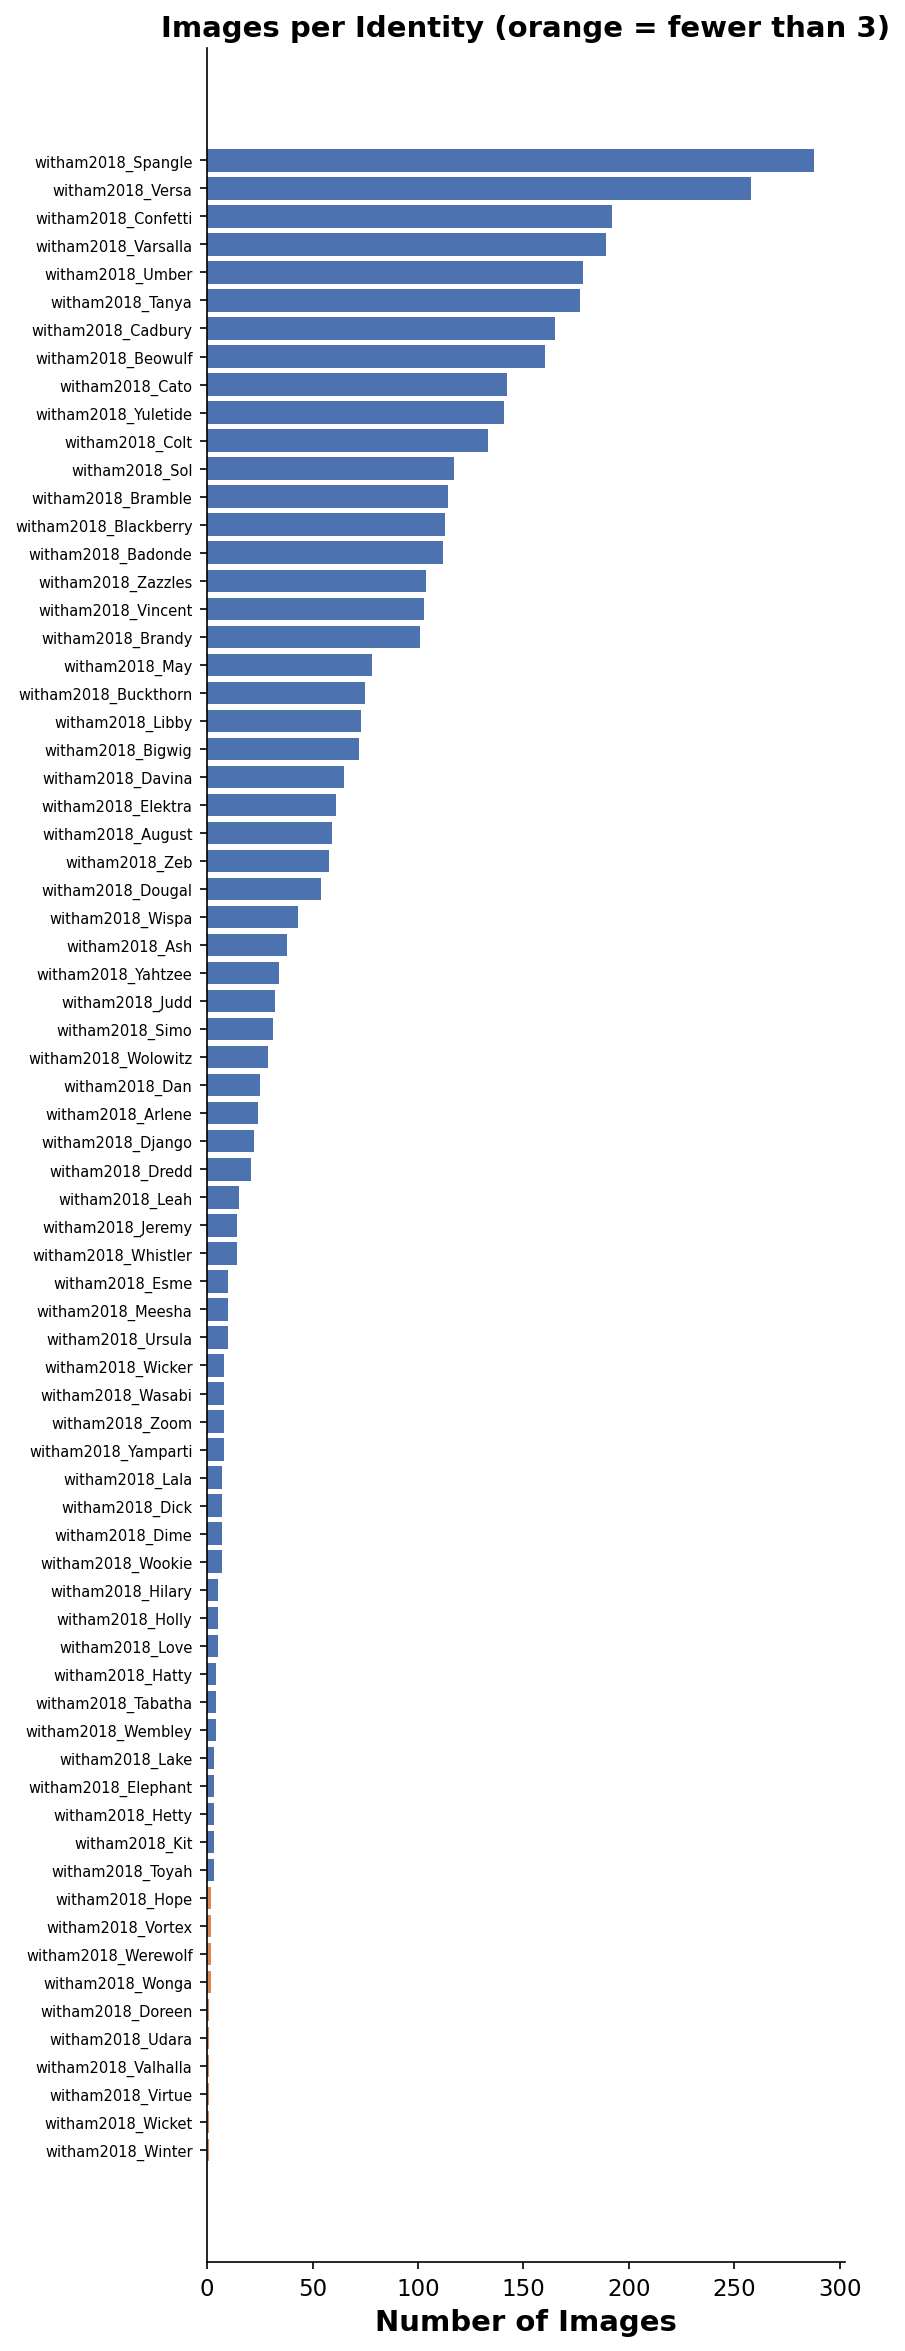

Total images: 3870, Unique IDs: 72
IDs with >= 3 images: 62
Class imbalance ratio (max/min): 288.0x
Range: 1-288 images per ID


In [7]:
# Class balance visualization
import collections

if DATASET_ROOT and Path(DATASET_ROOT).is_dir():
    allowed_ext = {'.jpg', '.jpeg', '.png'}
    all_files = [f for f in Path(DATASET_ROOT).iterdir() if f.suffix.lower() in allowed_ext]

    # Extract identity from filename
    id_list = []
    for f in all_files:
        stem = f.stem
        if ' ' in stem:
            id_list.append(stem.split(' ', 1)[0])
        elif '_' in stem and '-' in stem:
            after_underscore = stem.split('_', 1)[1]
            id_list.append(after_underscore.split('-', 1)[0])
        elif f.parent != Path(DATASET_ROOT):
            id_list.append(f.parent.name)

    id_counts = collections.Counter(id_list)
    sorted_ids = id_counts.most_common()
    names = [x[0] for x in sorted_ids]
    counts = [x[1] for x in sorted_ids]

    fig, ax = plt.subplots(figsize=(6, max(3, len(names) * 0.22)))
    colors = ['#4C72B0' if c >= 3 else '#DD8452' for c in counts]
    ax.barh(range(len(names)), counts, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xlabel('Number of Images')
    ax.set_title('Images per Identity (orange = fewer than 3)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Summary stats
    n_total = len(id_list)
    n_ids = len(id_counts)
    n_ids_ge3 = sum(1 for c in counts if c >= 3)
    imbalance = max(counts) / max(min(counts), 1)
    print(f'Total images: {n_total}, Unique IDs: {n_ids}')
    print(f'IDs with >= 3 images: {n_ids_ge3}')
    print(f'Class imbalance ratio (max/min): {imbalance:.1f}x')
    print(f'Range: {min(counts)}-{max(counts)} images per ID')


## 4. Run the Recognition Pipeline

This is the main part of the notebook. The following cell will execute the entire pipeline using the dataset you selected above.

**Pipeline Steps:**
1.  **Load Models**: Initializes the MMDetection and MMPose models.
2.  **Detect & Align**: Finds faces in your source images, estimates landmarks, and saves aligned 112x112 pixel crops.
3.  **Extract Embeddings**: Converts each aligned face into a 512-dimension feature vector (an "embedding").
4.  **Train & Evaluate Classifier**: Trains an SVM classifier on the embeddings and evaluates its accuracy on a test set.
5.  **Run Shuffle Control**: Trains a second classifier on shuffled labels to ensure the model is learning real features, not just noise.

This process can take several minutes, depending on the size of your dataset and the GPU assigned to you.

Models not found. Initializing now...
Loading MMDetection model...


Loads checkpoint by local backend from path: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os-bench\demos\mmdet_checkpoint.pth


Loading MMPose model...
Loads checkpoint by local backend from path: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os-bench\demos\mmpose_checkpoint.pth


Detector and pose models loaded successfully.
Image paths not yet loaded. Loading a small sample for the preview...
Scanning for images in A:\NonEnclosureProjects\inprep\PrimateFace\data\external_animal_data\witham_mac...


Found 3870 images across 72 initial unique IDs.
Found 72 IDs with at least 1 samples each.

---> Final dataset for pipeline: 3870 images from 72 individuals.
First 5 unique IDs being used: ['witham2018_Arlene', 'witham2018_Ash', 'witham2018_August', 'witham2018_Badonde', 'witham2018_Beowulf']

Generating preview for 3 random images...
Processing image 1/3...


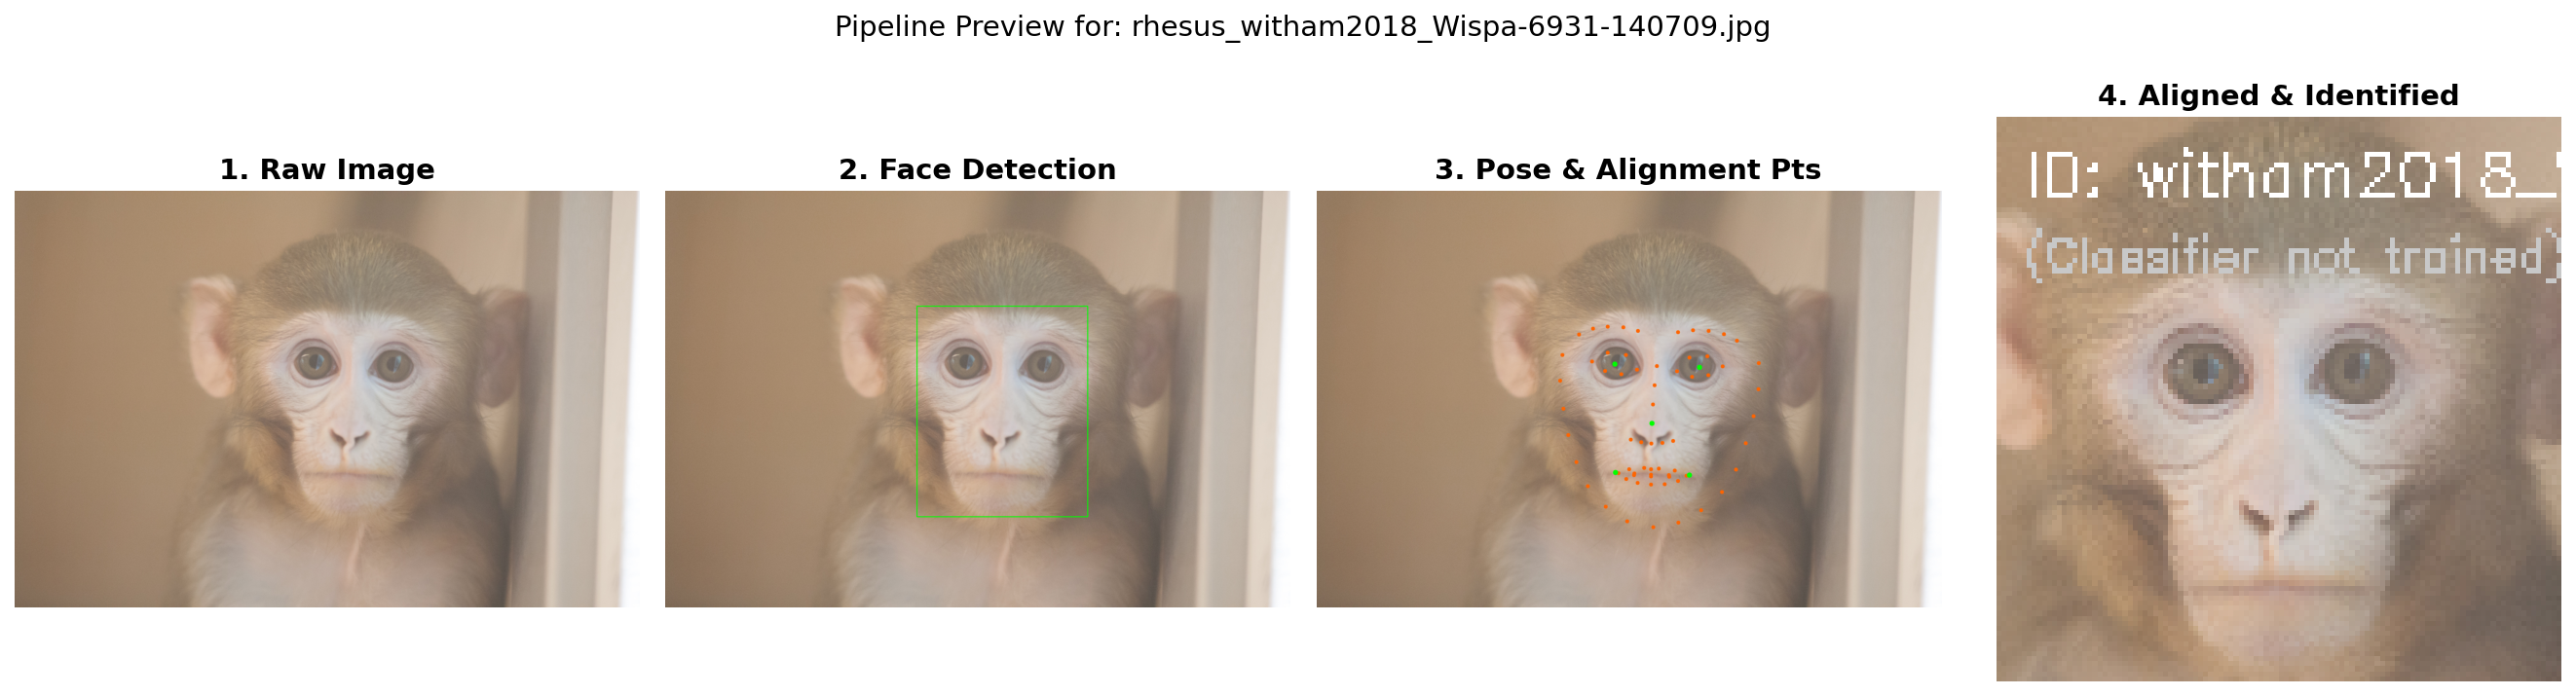

Processing image 2/3...


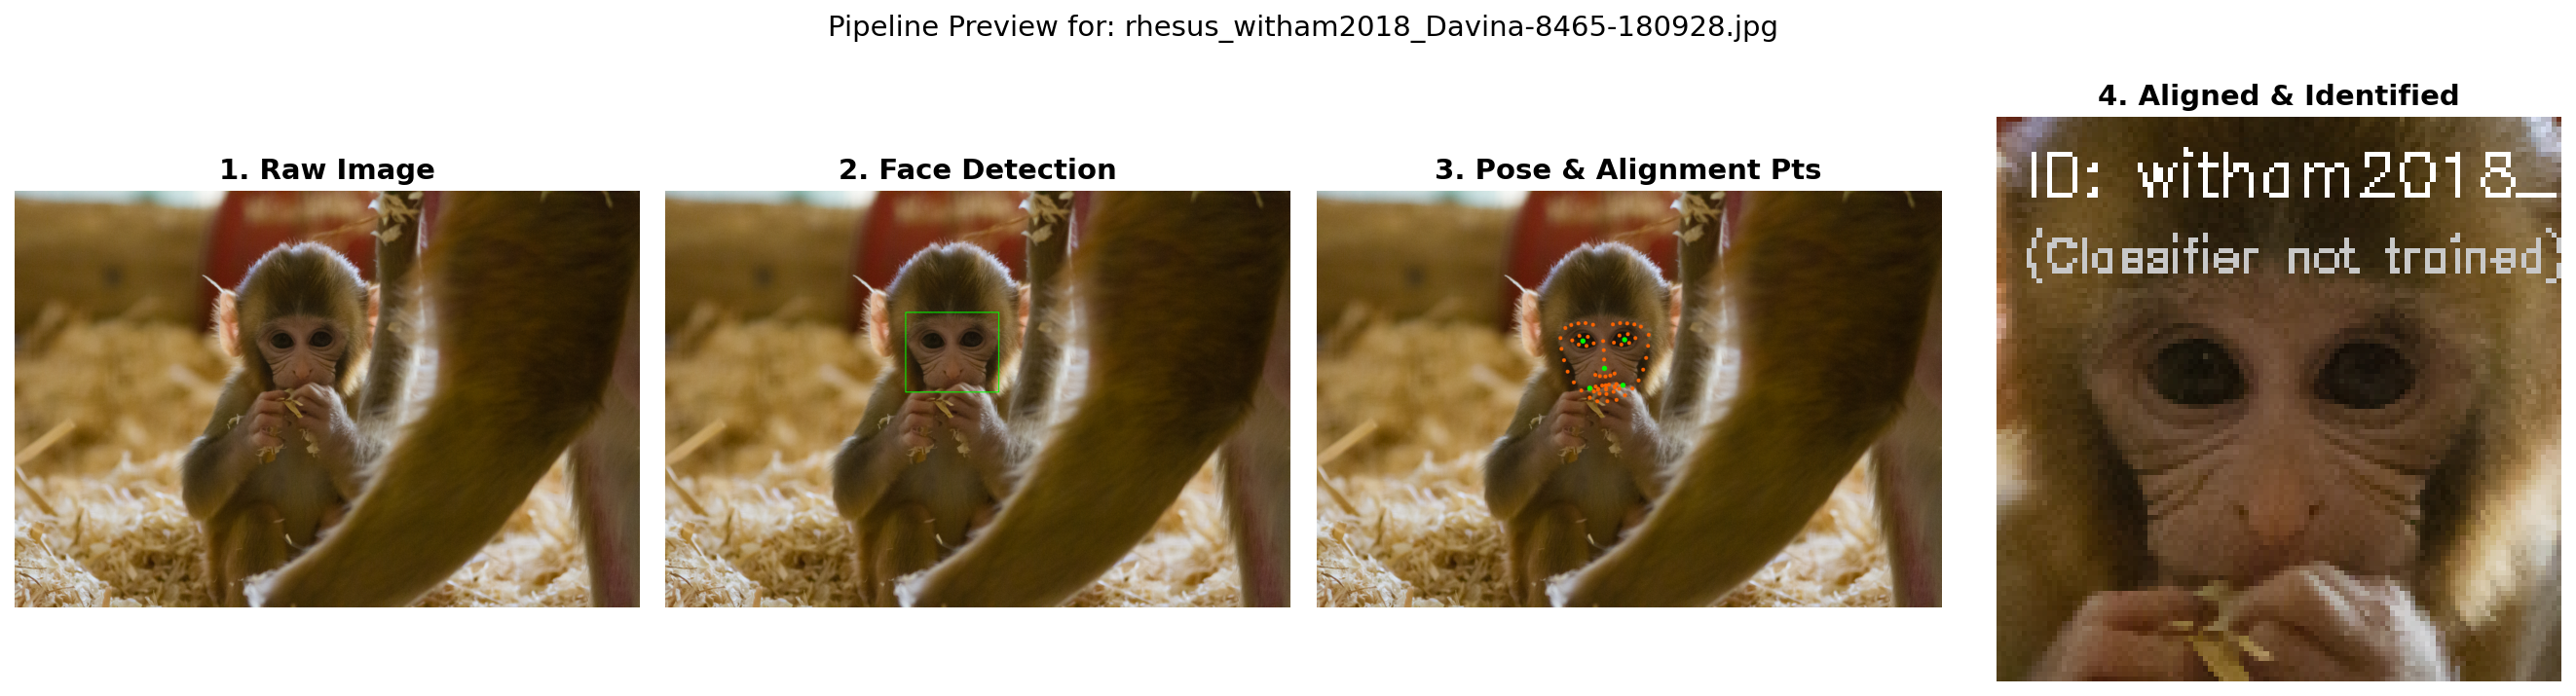

Processing image 3/3...


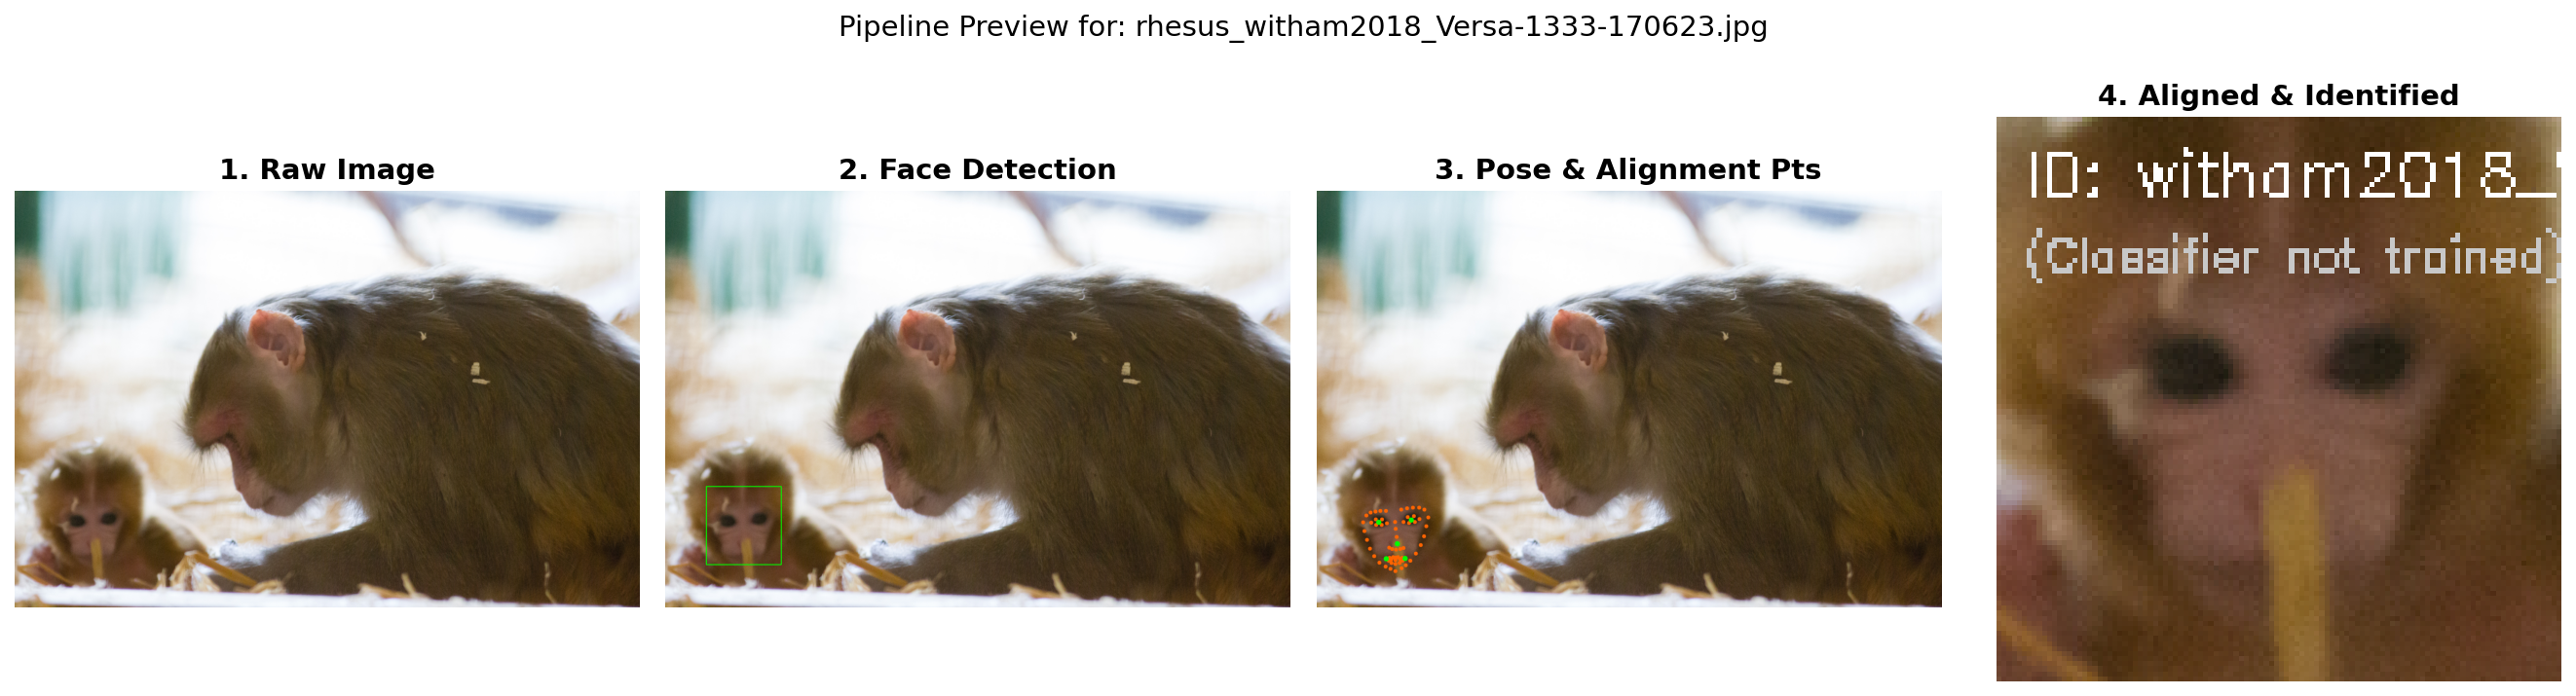

In [8]:

num_preview_images = 3
import collections
import random
import cv2
import matplotlib.pyplot as plt
processing_device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# --- Helper to safely convert to numpy ---
def to_numpy(data):
    return data.cpu().numpy() if torch.is_tensor(data) else data

# --- Step 1: Ensure Models are Loaded (or Load Them Now) ---
# Use 'globals()' to check if variables exist at the notebook's global scope
if 'detector_model' not in globals() or detector_model is None or 'mmpose_model' not in globals() or mmpose_model is None:
    print("Models not found. Initializing now...")
    try:
        detector_model, mmpose_model = init_models(
            str(MMDET_CONFIG_PATH), str(MMDET_CHECKPOINT_PATH),
            str(MMPOSE_CONFIG_PATH), str(MMPOSE_CHECKPOINT_PATH),
            device=processing_device,
        )
        print("Detector and pose models loaded successfully.")
    except Exception as e:
        print(f"FATAL: Could not load models. Please check paths in previous cells. Error: {e}")
        detector_model = None
        mmpose_model = None

# --- Step 2: Ensure Data is Loaded (or Load It Now) ---
# Use 'globals()' again to check for data lists
if 'source_paths' not in globals() or not source_paths:
    print("Image paths not yet loaded. Loading a small sample for the preview...")
    try:
        # We load with a min_samples of 1 just for the preview to ensure we get some data
        source_paths, assigned_ids, unique_ids = load_user_images_and_assign_ids(
            DATA_SOURCE_PATH,
            min_samples_per_id=1
        )
    except Exception as e:
        print(f"FATAL: Could not load data. Please check your data source path. Error: {e}")
        source_paths = [] # Ensure it's empty on failure

# --- Main Preview Logic ---
if detector_model and mmpose_model and source_paths:
    print(f"\nGenerating preview for {num_preview_images} random images...")

    # Get random indices for our preview images
    if len(source_paths) >= num_preview_images:
        preview_indices = random.sample(range(len(source_paths)), num_preview_images)
    else:
        preview_indices = range(len(source_paths))

    # Process and plot each selected image
    for i, idx in enumerate(preview_indices):
        print(f"Processing image {i+1}/{num_preview_images}...")

        im_path = source_paths[idx]
        ground_truth_id = assigned_ids[idx]

        img_bgr = cv2.imread(str(im_path))
        if img_bgr is None:
            print(f"  - Could not load image: {im_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        plt.suptitle(f"Pipeline Preview for: {im_path.name}", fontsize=14)

        axes[0].imshow(img_rgb)
        axes[0].set_title("1. Raw Image")
        axes[0].axis('off')

        try:
            # Detection
            out_mmdet = inference_detector(detector_model, img_bgr)
            pred_instances = out_mmdet.pred_instances
            scores = to_numpy(pred_instances.scores)
            bboxes = to_numpy(pred_instances.bboxes)
            best_bbox = bboxes[scores.argmax()]

            img_with_bbox = img_rgb.copy()
            x1, y1, x2, y2 = map(int, best_bbox)
            cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (0, 255, 0), 2)
            axes[1].imshow(img_with_bbox)
            axes[1].set_title("2. Face Detection")
            axes[1].axis('off')

            # Pose Estimation
            pose_results = inference_topdown(mmpose_model, img_bgr, [best_bbox], bbox_format='xyxy')
            landmarks_68 = to_numpy(pose_results[0].pred_instances.keypoints[0])
            source_5pts = get_5_source_landmarks_from_68(landmarks_68)

            img_with_pose = img_rgb.copy()
            for x, y in landmarks_68:
                cv2.circle(img_with_pose, (int(x), int(y)), 6, (255, 100, 0), -1)
            for x, y in source_5pts:
                cv2.circle(img_with_pose, (int(x), int(y)), 8, (0, 255, 0), -1)
            axes[2].imshow(img_with_pose)
            axes[2].set_title("3. Pose & Alignment Pts")
            axes[2].axis('off')

            # Alignment and Identification
            aligned_bgr, _ = align_face(img_bgr, landmarks_68, output_size=112, target_landmarks=TARGET_LANDMARKS_5PT_112X112)
            aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)

            text_to_display = f"ID: {ground_truth_id}\n(Classifier not trained)"
            # Check if classifier has been trained
            if 'best_clf' in globals() and best_clf is not None:
                embedding = get_embedding(aligned_bgr)
                pred_idx = best_clf.predict([embedding])
                pred_id = le.inverse_transform(pred_idx)[0]
                text_to_display = f"Predicted ID: {pred_id}"

            cv2.putText(aligned_rgb, text_to_display.split('\n')[0], (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            if '\n' in text_to_display:
                cv2.putText(aligned_rgb, text_to_display.split('\n')[1], (5, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (200, 200, 200), 1)

            axes[3].imshow(aligned_rgb)
            axes[3].set_title("4. Aligned & Identified")
            axes[3].axis('off')

        except Exception as e:
            error_text = f"Preview failed:\n{e}"
            print(f"  - {error_text}")
            axes[1].text(0.5, 0.5, error_text, ha='center', va='center', wrap=True, color='red')
            axes[1].axis('off'); axes[2].axis('off'); axes[3].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

else:
    print("\n❌ Preview could not run. Please check the error messages above and ensure all previous setup cells have run successfully.")

In [9]:

apply_augmentation = False
FIGURES_OUTPUT_DIR = "figures_recognition_demo"
min_samples_per_id = 5

import os

processing_device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
EMBEDDINGS_FILE = "embeddings.npz"

# Initialize variables to hold our data
X_embed, y_labels, img_paths = None, None, None

# --- Smart Checkpoint Logic ---
if os.path.exists(EMBEDDINGS_FILE):
    print(f"✅ Found existing embeddings file: '{EMBEDDINGS_FILE}'")
    print("⏩ Skipping detection and embedding steps and jumping straight to training.")

    # --- CRITICAL WARNING FOR THE USER ---
    print("\n" + "="*60)
    print("❗ IMPORTANT: You are using a pre-existing checkpoint file.")
    print("   If you have changed your dataset or the `min_samples_per_id`")
    print("   setting, you MUST delete this file first! To do so:")
    print("   1. Click the 'Files' icon on the left sidebar.")
    print(f"   2. Right-click on '{EMBEDDINGS_FILE}' and choose 'Delete'.")
    print("   3. Rerun this cell.")
    print("="*60 + "\n")

    try:
        data = np.load(EMBEDDINGS_FILE, allow_pickle=True)
        X_embed = data['X']
        y_labels = data['y']
        img_paths = data['paths']
        print(f"Successfully loaded {X_embed.shape[0]} embeddings.")
    except Exception as e:
        print(f"Error loading {EMBEDDINGS_FILE}: {e}. Please delete it and rerun.")
        X_embed = None # Ensure it's None on failure

else:
    print(f"No checkpoint file found. Running the full pipeline from scratch...\n")

    # --- Full pipeline logic (only runs if the .npz file doesn't exist) ---
    # 1. Initialize Models (if not already loaded)
    print("--- 1. Initializing Models ---")
    if 'detector_model' not in globals() or detector_model is None or 'mmpose_model' not in globals() or mmpose_model is None:
        detector_model, mmpose_model = init_models(
            str(MMDET_CONFIG_PATH), str(MMDET_CHECKPOINT_PATH),
            str(MMPOSE_CONFIG_PATH), str(MMPOSE_CHECKPOINT_PATH),
            device=processing_device,
        )
    print("-" * 30)

    # 2. Prepare image paths and IDs
    print("\n--- 2. Preparing Dataset ---")
    source_paths, assigned_ids, unique_ids = load_user_images_and_assign_ids(
        DATA_SOURCE_PATH, min_samples_per_id=min_samples_per_id
    )

    # 3. Detect, Align, and Crop Faces
    print("\n--- 3. Detecting, Aligning, and Cropping Faces ---")
    output_base_dir = Path("primate_recognition_demo")
    crop_dir = detect_and_crop_faces(detector_model, source_paths, assigned_ids, output_base_dir)
    CROP_DIR = crop_dir  # store for benchmark cell

    # 4. Extract Embeddings
    print("\n--- 4. Extracting Face Embeddings ---")
    X_embed, y_labels, img_paths = extract_embeddings_direct(crop_dir)

# --- Classifier Training (runs in both cases) ---
if X_embed is not None and len(X_embed) > 0:
    # Now, filter the loaded or generated data based on the current min_samples setting
    print("\n--- 5. Filtering Data and Training Classifier ---")

    # This is a crucial safety step: we re-filter the loaded data
    id_counts = collections.Counter(y_labels)
    valid_ids = {id_ for id_, count in id_counts.items() if count >= min_samples_per_id}

    mask = [label in valid_ids for label in y_labels]
    X_filtered = X_embed[mask]
    y_filtered = np.array(y_labels)[mask]
    paths_filtered = np.array(img_paths)[mask]

    print(f"Filtered embeddings down to {len(X_filtered)} samples from {len(valid_ids)} individuals.")

    if len(X_filtered) > 0:
        (best_clf, le, final_acc, bal_acc, X_tr_final, y_tr_final,
         X_te, y_te, y_pred, y_prob) = train_classifier(X_filtered, y_filtered, paths_filtered, augment=apply_augmentation)

        # ... (Rest of the plotting and analysis code is the same) ...

No checkpoint file found. Running the full pipeline from scratch...

--- 1. Initializing Models ---
------------------------------

--- 2. Preparing Dataset ---
Scanning for images in A:\NonEnclosureProjects\inprep\PrimateFace\data\external_animal_data\witham_mac...


Found 3870 images across 72 initial unique IDs.
Found 54 IDs with at least 5 samples each.

---> Final dataset for pipeline: 3829 images from 54 individuals.
First 5 unique IDs being used: ['witham2018_Arlene', 'witham2018_Ash', 'witham2018_August', 'witham2018_Badonde', 'witham2018_Beowulf']

--- 3. Detecting, Aligning, and Cropping Faces ---
Detecting, aligning, and cropping faces...


Detecting & Aligning:   0%|          | 0/3829 [00:00<?, ?it/s]

Aligned face crops saved to primate_recognition_demo\crops

--- 4. Extracting Face Embeddings ---
Extracting embeddings...


Extracting Embeddings:   0%|          | 0/3813 [00:00<?, ?it/s]

Embeddings saved to embeddings.npz. Shape: (3813, 512)

--- 5. Filtering Data and Training Classifier ---
Filtered embeddings down to 3813 samples from 54 individuals.
Training ID classifiers with GridSearchCV...

Running GridSearchCV for SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best SVM params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM cross-validation accuracy: 0.8232

Running GridSearchCV for MLPClassifier...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best MLP params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'max_iter': 500}
Best MLP cross-validation accuracy: 0.7445

SVM selected as best model.


Final accuracy on held-out test set: 0.8374
Balanced accuracy on held-out test set: 0.8011


## 5. Embedding Model Comparison

PrimateFace provides the upstream pipeline: detection → 68-point landmarks → aligned 112×112 crops.
The embedding model is a downstream choice — we show the pipeline is plug-and-play by testing three
models from different training domains:

- **ArcFace (buffalo_l)**: Human face recognition model (512-d)
- **MegaDescriptor-L-384**: Wildlife re-identification foundation model (1536-d)
- **DINOv2 (ViT-S/14)**: General-purpose self-supervised vision model (384-d)

Same aligned crops, same SVM classifier, same train/test split.

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [10]:
# 3-way embedding comparison: ArcFace vs MegaDescriptor vs DINOv2
# Uses the same aligned crops from the main pipeline.

import timm
from torchvision import transforms as T

# --- Helper functions for alternative embedding models ---

def load_megadescriptor():
    """Load MegaDescriptor-L-384 wildlife re-ID model."""
    print("Loading MegaDescriptor-L-384...")
    model = timm.create_model("hf-hub:BVRA/MegaDescriptor-L-384", pretrained=True)
    model.eval().to(processing_device)
    transform = timm.data.create_transform(**timm.data.resolve_data_config(model.pretrained_cfg))
    print(f"  MegaDescriptor loaded. Embedding dim: {model.num_features}")
    return model, transform

def get_embedding_mega(image_bgr, model, transform):
    """Extract MegaDescriptor embedding from a BGR image."""
    from PIL import Image
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)
    tensor = transform(pil_img).unsqueeze(0).to(processing_device)
    with torch.no_grad():
        emb = model(tensor)
    return emb.cpu().numpy().flatten()

def load_dinov2(model_name: str = "dinov2_vits14"):
    """Load DINOv2 ViT-S/14 from torch hub."""
    print(f"Loading {model_name}...")
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(processing_device)
    embed_dim = model.embed_dim if hasattr(model, 'embed_dim') else 384
    print(f"  DINOv2 loaded. Embedding dim: {embed_dim}")
    return model

def get_embedding_dinov2(image_bgr, model, size=224):
    """Extract DINOv2 embedding from a BGR image."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(rgb, (size, size)).astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1)
    tensor = T.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])(tensor)
    with torch.no_grad():
        emb = model(tensor.unsqueeze(0).to(processing_device))
    return emb.cpu().numpy().flatten()

# --- Find crop directory ---
# The main pipeline saves crops; find them
crop_dir = None
for candidate in [
    Path("primate_recognition_demo") / "crops",
    Path(FIGURES_OUTPUT_DIR).parent / "crops",
]:
    if candidate.exists() and list(candidate.glob("*.jpg")) + list(candidate.glob("*.png")):
        crop_dir = candidate
        break

if crop_dir is None:
    print("ERROR: No crop directory found. Run the main pipeline (Section 4) first.")
else:
    crop_files = sorted(list(crop_dir.glob("*.jpg")) + list(crop_dir.glob("*.png")))
    print(f"Found {len(crop_files)} crops in {crop_dir}")

    # Parse labels from filenames (format: ID_restofname.jpg)
    crop_labels = []
    for f in crop_files:
        label = "_".join(f.stem.split("_")[:2])
        crop_labels.append(label)

    # Load models
    mega_model, mega_transform = load_megadescriptor()
    dino_model = load_dinov2()

    # Extract embeddings for all 3 models
    results = {}
    for model_name, extract_fn in [
        ("ArcFace (512-d)", lambda img: get_embedding(img).flatten()),
        ("MegaDescriptor (1536-d)", lambda img: get_embedding_mega(img, mega_model, mega_transform)),
        ("DINOv2 (384-d)", lambda img: get_embedding_dinov2(img, dino_model)),
    ]:
        print(f"\nExtracting {model_name} embeddings...")
        embeddings = []
        labels = []
        for crop_path, label in tqdm(zip(crop_files, crop_labels), total=len(crop_files), desc=model_name):
            bgr = cv2.imread(str(crop_path))
            if bgr is None:
                continue
            try:
                emb = extract_fn(bgr)
                embeddings.append(emb)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {crop_path.name}: {e}")
                continue

        X = np.array(embeddings)
        y = np.array(labels)
        print(f"  {model_name}: {X.shape[0]} embeddings, dim={X.shape[1]}")

        # Train SVM on same split
        from sklearn.model_selection import train_test_split
        from sklearn.svm import SVC
        from sklearn.metrics import accuracy_score, balanced_accuracy_score
        from sklearn.preprocessing import LabelEncoder

        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_enc, test_size=0.3, stratify=y_enc, random_state=42
        )
        clf = SVC(kernel="rbf", C=10, gamma="scale")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        print(f"  Accuracy: {acc:.1%}  |  Balanced: {bal_acc:.1%}")
        results[model_name] = {"acc": acc, "bal_acc": bal_acc, "dim": X.shape[1]}

    # --- Comparison bar chart ---
    fig, ax = plt.subplots(figsize=(8, 5))
    models = list(results.keys())
    x = np.arange(len(models))
    width = 0.35

    acc_vals = [results[m]["acc"] * 100 for m in models]
    bal_vals = [results[m]["bal_acc"] * 100 for m in models]

    bars1 = ax.bar(x - width/2, acc_vals, width, label="Accuracy")
    bars2 = ax.bar(x + width/2, bal_vals, width, label="Balanced Accuracy")

    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Face Recognition: Same Crops, Different Embeddings")
    ax.set_xticks(x)
    ax.set_xticklabels([m.split(" (")[0] for m in models])
    ax.legend()
    ax.set_ylim(0, 100)

    # Annotate bars with values
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()
    save_fig(fig, "embedding_comparison", out_dir=FIGURES_OUTPUT_DIR)
    plt.close()

    # Summary table
    print("\n" + "=" * 60)
    print(f"{'Model':<25} {'Dim':>5} {'Acc':>8} {'Bal Acc':>8}")
    print("-" * 60)
    for m in models:
        r = results[m]
        print(f"{m:<25} {r['dim']:>5} {r['acc']:>7.1%} {r['bal_acc']:>7.1%}")
    print("=" * 60)
    print("\nAll models use the same PrimateFace-aligned 112x112 crops + SVM (RBF, C=10).")

Found 3813 crops in primate_recognition_demo\crops
Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

C:\ProgramData\miniconda3\envs\primateface\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Felipe Parodi\.cache\huggingface\hub\models--BVRA--MegaDescriptor-L-384. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

...

Using cache found in C:\Users\Felipe Parodi/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Felipe Parodi/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Felipe Parodi/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Felipe Parodi/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  DINOv2 loaded. Embedding dim: 384

Extracting ArcFace (512-d) embeddings...


ArcFace (512-d):   0%|          | 0/3813 [00:00<?, ?it/s]

  ArcFace (512-d): 3813 embeddings, dim=512


ValueError: The number of classes has to be greater than one; got 1 class

## 6. Recognition Scaling Curve

How does recognition accuracy scale with the number of images per identity?
We subsample to exactly *N* images per ID (only using IDs that have at least *N*),
then train and evaluate. This answers: **how much data do I need per individual?**

In [ ]:
# Scaling curve: accuracy vs images-per-identity
# Uses cached embeddings from the main pipeline above.

EMBEDDINGS_FILE = "embeddings.npz"
N_VALUES = [5, 10, 20, 50, 100]  # images per ID to test

if not os.path.exists(EMBEDDINGS_FILE):
    print("No embeddings file found. Run the main pipeline first.")
else:
    data = np.load(EMBEDDINGS_FILE, allow_pickle=True)
    X_all = data['X']
    y_all = data['y']
    paths_all = data.get('paths', np.array([]))

    from collections import Counter
    id_counts = Counter(y_all)

    results_n = []  # (n, n_ids, acc, bal_acc)

    for n in N_VALUES:
        # Filter to IDs with >= n images
        valid_ids = {k for k, v in id_counts.items() if v >= n}
        if len(valid_ids) < 2:
            print(f"N={n:3d}: fewer than 2 IDs have >= {n} images, skipping")
            continue

        # Subsample exactly n images per ID
        rng_sub = np.random.default_rng(42)
        mask = np.zeros(len(y_all), dtype=bool)
        for vid in valid_ids:
            idx = np.where(y_all == vid)[0]
            chosen = rng_sub.choice(idx, size=n, replace=False)
            mask[chosen] = True

        X_sub = X_all[mask]
        y_sub = y_all[mask]

        # Train/test split
        from sklearn.model_selection import train_test_split
        from sklearn.svm import SVC
        from sklearn.metrics import balanced_accuracy_score
        le_sub = LabelEncoder().fit(y_sub)
        y_enc = le_sub.transform(y_sub)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y_enc, test_size=0.3, stratify=y_enc, random_state=0
        )

        clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=0)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = np.mean(y_pred == y_te)
        bal = balanced_accuracy_score(y_te, y_pred)

        results_n.append((n, len(valid_ids), acc, bal))
        print(f"N={n:3d}  IDs={len(valid_ids):2d}  acc={acc:.3f}  bal_acc={bal:.3f}")

    if results_n:
        ns, n_ids, accs, bals = zip(*results_n)

        fig, ax1 = plt.subplots(figsize=(7, 4))
        ax1.plot(ns, accs, 'o-', color='#4C72B0', label='Accuracy', linewidth=2)
        ax1.plot(ns, bals, 's--', color='#DD8452', label='Balanced Accuracy', linewidth=2)
        ax1.set_xlabel('Images per Identity (N)')
        ax1.set_ylabel('Classification Accuracy')
        ax1.set_title('Face Recognition Scaling Curve')
        ax1.set_ylim(0, 1.05)
        ax1.legend(loc='lower right')
        ax1.grid(True, linestyle=':', alpha=0.5)

        # Annotate with number of IDs at each point
        for x, y, nid in zip(ns, accs, n_ids):
            ax1.annotate(f'{nid} IDs', (x, y), textcoords='offset points',
                         xytext=(0, 10), ha='center', fontsize=8, color='gray')

        plt.tight_layout()
        save_fig(fig, 'scaling_curve', out_dir=FIGURES_OUTPUT_DIR)
        plt.show()
    else:
        print("Not enough data for scaling curve.")


## 7. Review Results

The figures below summarize the performance of the face recognition pipeline on your dataset. They have been saved to the `figures_recognition_demo` directory.

*   **t-SNE Embeddings Plot**: This plot visualizes the high-dimensional (512-D) face embeddings in a 2D space. Ideally, embeddings from the same individual (same color) should cluster together, while embeddings from different individuals should be separated. This shows how well the recognition model distinguishes between faces.

*   **Confusion Matrix**: This matrix shows the classifier's performance. The diagonal represents correct identifications. Off-diagonal cells show misidentifications (e.g., if the model confuses ID_01 with ID_02). Values are normalized, so 1.0 on the diagonal is perfect accuracy for that ID.

*   **Image Retrieval Grid**: This shows a few random "query" images from the test set. For each query, the system finds the top 3 most similar-looking faces from the entire dataset based on their embeddings. This demonstrates the power of embeddings for similarity search.

*   **One-vs-Rest (OvR) ROC Curves**: This plot evaluates the classifier's ability to distinguish each individual against all others. An Area Under the Curve (AUC) of 1.0 is perfect, while 0.5 is equivalent to random chance. The micro- and macro-averages provide an overall sense of classifier performance across all individuals.

*   **Shuffle Control Summary**: This bar chart is a critical sanity check. It compares the accuracy of the model trained on real labels to one trained on shuffled (randomized) labels. The "Actual Model" should perform significantly better than the "Shuffled" models and "Chance" level, confirming that it has learned meaningful, identity-specific features.

In [ ]:
import glob
from IPython.display import display, Image as IPImage

figure_files = glob.glob(f"{FIGURES_OUTPUT_DIR}/*.png")

if not figure_files:
    print("No figure files found. Please ensure the pipeline in the previous cell ran successfully.")
else:
    for f in sorted(figure_files):
        print(f"\n--- Displaying: {f} ---")
        display(IPImage(filename=f, width=600))

## 8. Summary and Next Steps

**Congratulations!** You have successfully run a complete face recognition pipeline.

**What we accomplished:**
1.  **Detected, Aligned, and Cropped** faces from your source images.
2.  **Extracted** a unique 512-dimensional embedding for each face.
3.  **Trained** a classifier (SVM or MLP) to identify individuals from these embeddings.
4.  **Evaluated** the classifier's performance and confirmed its validity with a shuffle control experiment.
5.  **Visualized** the results with plots that help interpret the model's behavior.

**Next Steps:**
*   **Explore the Figures**: Analyze the confusion matrix to see which individuals are easily confused. Look at the t-SNE plot to understand the overall separability of your individuals.
*   **Adapt to Your Data**: Use this notebook as a template. Point it to your own datasets, try different MMDetection models from the PrimateFace zoo, or even train a classifier on a larger gallery of known individuals.
*   **Use the Classifier**: The trained `best_clf` object and the `LabelEncoder` (`le`) can be saved and used to predict the identity of new, unseen faces.

## 9. Resources
1. [PrimateFace](https://github.com/KordingLab/PrimateFace)
2. [mmdetection](https://github.com/open-mmlab/mmdetection)
3. [mmpose](https://github.com/open-mmlab/mmpose)
4. [InsightFace](https://github.com/deepinsight/insightface)